# GeoFlare — Notebook 02: Historical Baseline & Persistence

**Goal:** Go beyond a single snapshot. Build a per-location historical baseline from FIRMS data, then use it to tell apart **persistent thermal sources** (e.g. industrial sites) from **one-off detections**, and flag **anomalous** activity relative to each location's own history.

### This notebook covers
1. Loading configuration and the cleaned output of Notebook 01
2. Downloading a longer historical FIRMS window (rolling 5-day chunks)
3. Cleaning the historical data (same rules as Notebook 01)
4. Building spatial grid cells
5. Computing per-cell historical baseline statistics
6. Computing persistence features (recurring vs one-off)
7. Scoring recent detections against the baseline (anomaly z-score)
8. Mapping persistent hotspots
9. Saving the baseline dataset for Notebook 03

> **Important:** Never put your FIRMS MAP_KEY directly into the notebook. Store it in `.env`.

## 0. Where this notebook fits

```text
NASA FIRMS
    ↓
Ingest → Clean → Explore → Visualize        (Notebook 01 — done)
    ↓
THIS NOTEBOOK: Historical baseline & persistence
    ↓
OSM geospatial context
    ↓
Feature engineering
    ↓
XGBoost classification
    ↓
SHAP explanations
    ↓
Risk scoring
    ↓
Dashboard
```

Core idea for this notebook:

**HOTSPOT ≠ FIRE.** A single detection is just a hotspot. Repeated detections at the same location over time indicate a **persistent thermal source**. What we build here — the baseline — is what lets a later detection be judged as "normal for this place" or "unusual for this place".

In [1]:
# Install once if needed:
# %pip install pandas numpy matplotlib requests python-dotenv

import os
import time
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from dotenv import load_dotenv

print("Imports successful.")

Imports successful.


In [2]:
PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DIR)
print("Processed data:", PROCESSED_DIR)

Project root: c:\Users\ASUS\Documents\Sidra\ThermoTech
Raw data: c:\Users\ASUS\Documents\Sidra\ThermoTech\data\raw
Processed data: c:\Users\ASUS\Documents\Sidra\ThermoTech\data\processed


## 1. Configure NASA FIRMS

Same `.env` file as Notebook 01:

```text
FIRMS_MAP_KEY=YOUR_KEY_HERE
```

In [3]:
load_dotenv(PROJECT_ROOT / "backend" / ".env")
FIRMS_MAP_KEY = os.getenv("FIRMS_MAP_KEY")

if FIRMS_MAP_KEY:
    print("FIRMS MAP_KEY loaded successfully.")
else:
    print("WARNING: FIRMS_MAP_KEY not found.")
    print("Expected .env location:", PROJECT_ROOT / "backend" / ".env")

FIRMS MAP_KEY loaded successfully.


## 2. Load the cleaned output from Notebook 01

This is our **"recent window"** — the last 7 days, already cleaned. We will later score these detections against the historical baseline we're about to build.

In [4]:
recent_file = PROCESSED_DIR / "firms_india_clean.csv"

if not recent_file.exists():
    raise FileNotFoundError(
        f"{recent_file} not found. Run Notebook 01 first to produce it."
    )

recent = pd.read_csv(recent_file, parse_dates=["acq_date", "acq_datetime"])

print("Recent window rows:", len(recent))
print("Recent window date range:", recent["acq_date"].min(), "→", recent["acq_date"].max())
display(recent.head())

Recent window rows: 1112
Recent window date range: 2026-09-05 00:00:00 → 2026-09-07 00:00:00


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,acq_time_clean,acq_datetime
0,27.95755,96.95478,334.77,0.44,0.38,2026-09-05,637,N,VIIRS,n,2.0NRT,285.13,5.26,D,637,2026-09-05 06:37:00
1,27.95821,96.95849,328.12,0.44,0.38,2026-09-05,637,N,VIIRS,n,2.0NRT,284.71,5.26,D,637,2026-09-05 06:37:00
2,6.17996,81.00569,341.03,0.40,0.37,2026-09-05,813,N,VIIRS,n,2.0NRT,302.13,2.48,D,813,2026-09-05 08:13:00
3,6.18050,81.00926,337.19,0.40,0.37,2026-09-05,813,N,VIIRS,n,2.0NRT,301.79,2.48,D,813,2026-09-05 08:13:00
4,6.18250,81.15936,336.90,0.40,0.37,2026-09-05,813,N,VIIRS,n,2.0NRT,302.46,3.84,D,813,2026-09-05 08:13:00


## 3. Download a longer historical window

**Why not just download 60 days in one request?** The FIRMS `area/csv` API caps `DAY_RANGE` at **10 days per request** for NRT sources. To build a real history we request several 5-day windows, stepping the end date backward, and concatenate them.

For the first baseline pass we target:
- **Region:** India (same as Notebook 01)
- **Source:** VIIRS_SNPP_NRT (same as Notebook 01)
- **Total history:** 60 days, in 5-day chunks

Raw chunks are cached to disk — if a chunk was already downloaded, we skip re-fetching it.

In [10]:
FIRMS_SOURCE = "VIIRS_SNPP_NRT"
AREA = "68,6,97,37"
MAX_DAY_RANGE = 5
HISTORY_DAYS = 60

# Build historical windows BEFORE the recent scoring window
recent_start = recent["acq_date"].min()
history_end = recent_start - timedelta(days=1)
history_start = history_end - timedelta(days=HISTORY_DAYS - 1)

start_dates = [
    history_start + timedelta(days=i)
    for i in range(0, HISTORY_DAYS, MAX_DAY_RANGE)
]

start_dates = [d.strftime("%Y-%m-%d") for d in start_dates]

print("Source:", FIRMS_SOURCE)
print("Area:", AREA)
print("Recent window starts:", recent_start.strftime("%Y-%m-%d"))
print(
    "Historical period:",
    history_start.strftime("%Y-%m-%d"),
    "→",
    history_end.strftime("%Y-%m-%d")
)
print(f"Number of chunks: {len(start_dates)}")
print("Chunk start dates:", start_dates)


Source: VIIRS_SNPP_NRT
Area: 68,6,97,37
Recent window starts: 2026-09-05
Historical period: 2026-07-07 → 2026-09-04
Number of chunks: 12
Chunk start dates: ['2026-07-07', '2026-07-12', '2026-07-17', '2026-07-22', '2026-07-27', '2026-08-01', '2026-08-06', '2026-08-11', '2026-08-16', '2026-08-21', '2026-08-26', '2026-08-31']


In [11]:
if not FIRMS_MAP_KEY:
    raise ValueError("FIRMS_MAP_KEY is missing.")

historical_chunks = []

for start_date in start_dates:
    chunk_file = (
        RAW_DIR
        / f"firms_{FIRMS_SOURCE.lower()}_india_{MAX_DAY_RANGE}d_{start_date}.csv"
    )

    if chunk_file.exists():
        print(f"Cached: {chunk_file.name}")

    else:
        url = (
            f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
            f"{FIRMS_MAP_KEY}/{FIRMS_SOURCE}/{AREA}/{MAX_DAY_RANGE}/{start_date}"
        )

        print(f"Downloading {start_date} ...")

        response = requests.get(url, timeout=(15, 90))
        if response.status_code != 200:
            print("NASA status:", response.status_code)
            print("NASA response:", response.text[:2000])
            print("Requested date:", start_date)
            raise RuntimeError("FIRMS API request failed.")

        chunk_file.write_bytes(response.content)

        print(
            f"Downloaded: {chunk_file.name} "
            f"({chunk_file.stat().st_size / 1024:.1f} KB)"
        )

        time.sleep(1)

    chunk_df = pd.read_csv(chunk_file)
    chunk_df["source_chunk_start_date"] = start_date
    historical_chunks.append(chunk_df)

print(f"\nDownloaded/loaded {len(historical_chunks)} chunks.")


Cached: firms_viirs_snpp_nrt_india_5d_2026-07-07.csv
Downloaded: firms_viirs_snpp_nrt_india_5d_2026-07-12.csv (6.5 KB)
Downloaded: firms_viirs_snpp_nrt_india_5d_2026-07-17.csv (43.4 KB)
Downloaded: firms_viirs_snpp_nrt_india_5d_2026-07-22.csv (61.3 KB)
Downloaded: firms_viirs_snpp_nrt_india_5d_2026-07-27.csv (72.6 KB)
Cached: firms_viirs_snpp_nrt_india_5d_2026-08-01.csv
Downloaded: firms_viirs_snpp_nrt_india_5d_2026-08-06.csv (51.6 KB)
Downloaded: firms_viirs_snpp_nrt_india_5d_2026-08-11.csv (51.2 KB)
Downloaded: firms_viirs_snpp_nrt_india_5d_2026-08-16.csv (68.2 KB)
Downloaded: firms_viirs_snpp_nrt_india_5d_2026-08-21.csv (68.9 KB)
Cached: firms_viirs_snpp_nrt_india_5d_2026-08-26.csv
Downloaded: firms_viirs_snpp_nrt_india_5d_2026-08-31.csv (114.9 KB)

Downloaded/loaded 12 chunks.


## 4. Combine and deduplicate

Consecutive 5-day windows can overlap by a day at the edges, and FIRMS can occasionally return the same detection more than once. We concatenate all chunks and drop exact duplicates on the fields that uniquely identify a detection.

In [12]:
historical_raw = pd.concat(historical_chunks, ignore_index=True)
print("Rows before dedup:", len(historical_raw))

dedup_keys = [c for c in ["latitude", "longitude", "acq_date", "acq_time", "satellite", "instrument"]
              if c in historical_raw.columns]
historical_raw = historical_raw.drop_duplicates(subset=dedup_keys).reset_index(drop=True)

print("Rows after dedup:", len(historical_raw))
print("Columns:", len(historical_raw.columns))
display(historical_raw.head())

Rows before dedup: 8518
Rows after dedup: 8518
Columns: 15


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,source_chunk_start_date
0,20.79483,85.25611,342.82,0.38,0.58,2026-07-07,701,N,VIIRS,n,2.0NRT,288.34,6.26,D,2026-07-07
1,20.89047,84.98204,326.66,0.39,0.59,2026-07-07,701,N,VIIRS,n,2.0NRT,287.40,3.33,D,2026-07-07
2,20.96803,85.17975,330.58,0.38,0.59,2026-07-07,701,N,VIIRS,n,2.0NRT,284.37,4.90,D,2026-07-07
3,6.69526,81.40427,367.00,0.32,0.54,2026-07-07,837,N,VIIRS,h,2.0NRT,306.49,7.06,D,2026-07-07
4,6.82730,81.14629,342.08,0.61,0.54,2026-07-07,837,N,VIIRS,n,2.0NRT,302.39,11.03,D,2026-07-07


## 5. Clean the historical data

Same cleaning rules as Notebook 01 — numeric conversion, `acq_datetime` construction, coordinate validation. Wrapped as a function this time since we're applying it beyond a single download.

In [13]:
def clean_firms_df(df):
    """Apply the same cleaning rules used in Notebook 01 to any raw FIRMS dataframe."""
    out = df.copy()

    numeric_cols = [
    "latitude", "longitude", "frp",
    "bright_ti4", "bright_ti5", "scan", "track"
]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    if "acq_date" in out.columns:
        out["acq_date"] = pd.to_datetime(out["acq_date"], errors="coerce")

    if "acq_time" in out.columns:
        time_str = (
            out["acq_time"].astype(str)
            .str.replace(r"\.0$", "", regex=True)
            .str.zfill(4)
        )
        out["acq_time_clean"] = time_str.str[:4]

    if {"acq_date", "acq_time_clean"}.issubset(out.columns):
        out["acq_datetime"] = pd.to_datetime(
            out["acq_date"].dt.strftime("%Y-%m-%d") + " " +
            out["acq_time_clean"].str[:2] + ":" +
            out["acq_time_clean"].str[2:4],
            errors="coerce"
        )

    if {"latitude", "longitude"}.issubset(out.columns):
        out = out[
            out["latitude"].between(-90, 90) &
            out["longitude"].between(-180, 180)
        ].copy()

    return out


historical = clean_firms_df(historical_raw)

print("Cleaned historical rows:", len(historical))
print("Historical date range:", historical["acq_date"].min(), "→", historical["acq_date"].max())
display(historical.head())

Cleaned historical rows: 8518
Historical date range: 2026-07-07 00:00:00 → 2026-09-04 00:00:00


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,source_chunk_start_date,acq_time_clean,acq_datetime
0,20.79483,85.25611,342.82,0.38,0.58,2026-07-07,701,N,VIIRS,n,2.0NRT,288.34,6.26,D,2026-07-07,0701,2026-07-07 07:01:00
1,20.89047,84.98204,326.66,0.39,0.59,2026-07-07,701,N,VIIRS,n,2.0NRT,287.40,3.33,D,2026-07-07,0701,2026-07-07 07:01:00
2,20.96803,85.17975,330.58,0.38,0.59,2026-07-07,701,N,VIIRS,n,2.0NRT,284.37,4.90,D,2026-07-07,0701,2026-07-07 07:01:00
3,6.69526,81.40427,367.00,0.32,0.54,2026-07-07,837,N,VIIRS,h,2.0NRT,306.49,7.06,D,2026-07-07,0837,2026-07-07 08:37:00
4,6.82730,81.14629,342.08,0.61,0.54,2026-07-07,837,N,VIIRS,n,2.0NRT,302.39,11.03,D,2026-07-07,0837,2026-07-07 08:37:00


## 6. Build spatial grid cells

Same grid approach as Notebook 01's spatial-concentration check: round latitude/longitude to 2 decimal places (roughly a 1km cell). Each grid cell becomes a candidate "location" for baseline statistics.

We add the same grid columns to both `historical` and `recent` so the two can be joined later.

In [15]:
for frame in (historical, recent):
    frame["lat_grid"] = frame["latitude"].round(2)
    frame["lon_grid"] = frame["longitude"].round(2)

print("Grid columns added to historical and recent frames.")
display(historical[["latitude", "longitude", "lat_grid", "lon_grid"]].head())

Grid columns added to historical and recent frames.


,latitude,longitude,lat_grid,lon_grid
0,20.79483,85.25611,20.79,85.26
1,20.89047,84.98204,20.89,84.98
2,20.96803,85.17975,20.97,85.18
3,6.69526,81.40427,6.70,81.40
4,6.82730,81.14629,6.83,81.15


## 7. Per-cell historical baseline statistics

For every grid cell, summarize its thermal history:
- how many detections it has had,
- typical (mean) and variability (std) of FRP,
- the strongest detection on record,
- first and last time it was seen.

This is the baseline that later detections get compared against.

In [16]:
baseline = (
    historical.groupby(["lat_grid", "lon_grid"])
    .agg(
        detection_count=("frp", "size"),
        frp_mean=("frp", "mean"),
        frp_std=("frp", "std"),
        frp_max=("frp", "max"),
        first_seen=("acq_date", "min"),
        last_seen=("acq_date", "max"),
        active_days=("acq_date", "nunique"),
    )
    .reset_index()
)

baseline["frp_std"] = baseline["frp_std"].fillna(0)

print("Grid cells with historical detections:", len(baseline))
display(baseline.sort_values("detection_count", ascending=False).head(10))

Grid cells with historical detections: 4855


,lat_grid,lon_grid,detection_count,frp_mean,frp_std,frp_max,first_seen,last_seen,active_days
3506,23.76,86.40,38,2.205000,1.465998,7.66,2026-07-22,2026-09-04,16
3457,23.68,86.40,34,2.769118,2.242002,9.10,2026-07-26,2026-09-04,11
3633,25.39,68.58,32,1.701563,0.805974,3.33,2026-07-09,2026-09-04,26
2896,15.18,76.67,31,2.076129,1.007223,5.17,2026-07-09,2026-09-04,16
3342,22.38,87.28,30,2.945000,1.960893,7.49,2026-07-25,2026-08-29,13
2895,15.18,76.66,29,2.530690,1.673610,8.44,2026-07-09,2026-09-04,16
3660,25.94,72.19,28,3.701786,4.078139,18.43,2026-07-20,2026-09-03,19
3528,23.78,86.39,27,2.531481,1.357899,5.89,2026-07-22,2026-09-04,14
3239,21.75,83.84,27,4.356667,3.108334,13.51,2026-07-30,2026-09-04,8
4834,35.99,94.83,25,0.946800,0.282794,1.79,2026-07-20,2026-09-03,19


## 8. Persistence features

A cell that was only ever seen once is a **one-off**. A cell seen on many distinct days across the whole history window is a **recurring / persistent** thermal source — the kind of pattern we'd expect from an industrial site rather than an isolated fire.

We compute:
- `days_span` — how many calendar days between first and last detection,
- `persistence_ratio` — fraction of that span the cell was actually active on,
- `is_recurring` — a simple threshold flag (3+ distinct active days) for a first pass.

In [17]:
baseline["days_span"] = (baseline["last_seen"] - baseline["first_seen"]).dt.days + 1
baseline["persistence_ratio"] = (baseline["active_days"] / baseline["days_span"]).round(3)

RECURRING_MIN_ACTIVE_DAYS = 3
baseline["is_recurring"] = baseline["active_days"] >= RECURRING_MIN_ACTIVE_DAYS

print("Recurring cells:", baseline["is_recurring"].sum())
print("One-off cells:", (~baseline["is_recurring"]).sum())
display(baseline.sort_values("persistence_ratio", ascending=False).head(10))

Recurring cells: 326
One-off cells: 4529


,lat_grid,lon_grid,detection_count,frp_mean,frp_std,frp_max,first_seen,last_seen,active_days,days_span,persistence_ratio,is_recurring
4854,37.00,80.20,1,0.81,0.0,0.81,2026-07-20,2026-07-20,1,1,1.0,False
0,6.11,81.09,1,4.57,0.0,4.57,2026-08-10,2026-08-10,1,1,1.0,False
1,6.16,80.93,1,4.42,0.0,4.42,2026-09-02,2026-09-02,1,1,1.0,False
2,6.16,81.11,2,11.68,0.0,11.68,2026-07-08,2026-07-08,1,1,1.0,False
3,6.17,80.89,1,1.55,0.0,1.55,2026-08-22,2026-08-22,1,1,1.0,False
4,6.19,80.72,1,1.55,0.0,1.55,2026-09-02,2026-09-02,1,1,1.0,False
5,6.20,81.02,1,3.17,0.0,3.17,2026-09-01,2026-09-01,1,1,1.0,False
4838,36.36,95.23,2,4.67,0.0,4.67,2026-09-04,2026-09-04,1,1,1.0,False
4837,36.35,95.24,1,8.54,0.0,8.54,2026-09-04,2026-09-04,1,1,1.0,False
4836,36.35,95.23,1,7.50,0.0,7.50,2026-09-04,2026-09-04,1,1,1.0,False


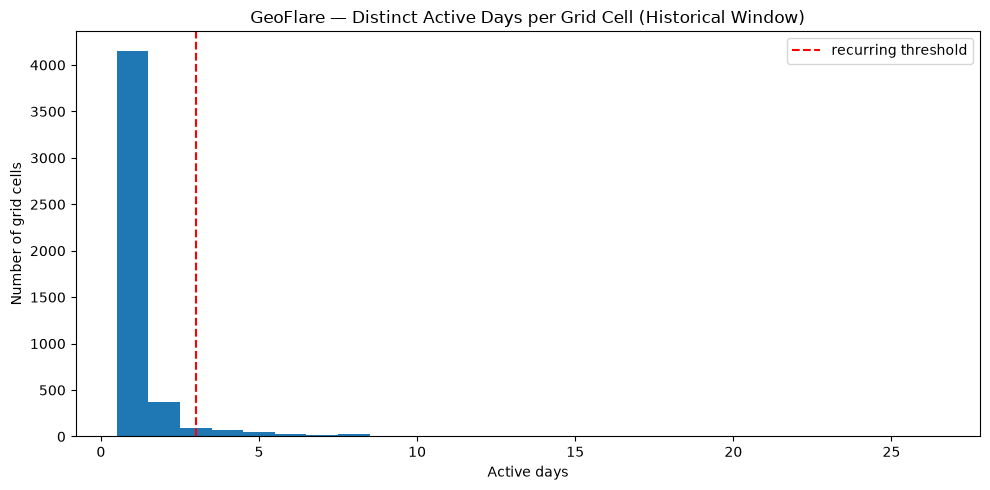

In [18]:
plt.figure(figsize=(10, 5))
plt.hist(baseline["active_days"], bins=range(1, baseline["active_days"].max() + 2), align="left")
plt.axvline(RECURRING_MIN_ACTIVE_DAYS, color="red", linestyle="--", label="recurring threshold")
plt.title("GeoFlare — Distinct Active Days per Grid Cell (Historical Window)")
plt.xlabel("Active days")
plt.ylabel("Number of grid cells")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Score recent detections against the baseline

Now bring in the **recent window** from Notebook 01. For each recent detection, look up its grid cell's historical baseline and compute an **FRP anomaly z-score**:

```text
z = (recent_frp − historical_mean_frp) / historical_std_frp
```

- A high positive `z` means "much hotter than this location's own history" — a candidate for a real event, not just background activity.
- Cells with **no history at all** are flagged separately (`has_baseline = False`) — these are brand-new locations, which are interesting for a different reason (first-ever detection).

In [19]:
scored = recent.merge(
    baseline[["lat_grid", "lon_grid", "detection_count", "frp_mean", "frp_std",
              "active_days", "persistence_ratio", "is_recurring"]],
    on=["lat_grid", "lon_grid"],
    how="left",
    suffixes=("", "_hist"),
)

scored["has_baseline"] = scored["detection_count"].notna()

# avoid divide-by-zero for cells with a single historical detection (std = 0 or NaN)
safe_std = scored["frp_std"].replace(0, np.nan)
scored["frp_zscore"] = (scored["frp"] - scored["frp_mean"]) / safe_std

print("Recent detections with a historical baseline:", scored["has_baseline"].sum())
print("Recent detections with NO prior history (new locations):", (~scored["has_baseline"]).sum())

Recent detections with a historical baseline: 466
Recent detections with NO prior history (new locations): 646


In [20]:
top_anomalies = scored[scored["has_baseline"]].sort_values("frp_zscore", ascending=False).head(20)

useful_cols = [c for c in [
    "latitude", "longitude", "acq_datetime", "frp", "frp_mean", "frp_std",
    "frp_zscore", "active_days", "is_recurring", "confidence"
] if c in top_anomalies.columns]

display(top_anomalies[useful_cols])

,latitude,longitude,acq_datetime,frp,frp_mean,frp_std,frp_zscore,active_days,is_recurring,confidence
1079,21.75690,83.84543,2026-09-07 07:39:00,7.87,2.905000,0.049497,100.308148,1.0,False,l
480,15.17463,76.78519,2026-09-05 20:46:00,2.58,0.805000,0.021213,83.674302,2.0,False,n
781,20.96956,86.01638,2026-09-06 07:58:00,7.92,0.890000,0.138564,50.734655,2.0,False,n
1080,21.76431,83.84805,2026-09-07 07:39:00,5.12,2.905000,0.049497,44.749758,1.0,False,l
1058,20.80732,85.25565,2026-09-07 07:39:00,7.38,1.515000,0.162635,36.062446,2.0,False,n
878,21.76197,83.84690,2026-09-06 20:27:00,4.30,2.905000,0.049497,28.183256,1.0,False,n
1068,20.96964,86.02120,2026-09-07 07:39:00,4.31,0.890000,0.138564,24.681724,2.0,False,n
1062,20.87168,84.99634,2026-09-07 07:39:00,8.12,1.653333,0.268390,24.094267,3.0,True,n
1086,22.57426,85.89369,2026-09-07 07:39:00,3.54,1.570000,0.113137,17.412504,2.0,False,n
1083,22.20925,84.86183,2026-09-07 07:39:00,3.47,1.580000,0.113137,16.705398,1.0,False,n


## 10. Map persistent hotspots

A first geographic view of the baseline itself: every grid cell that has ever fired, sized by how many times it fired and colored by how persistent it is. Dense, high-persistence clusters are the strongest early candidates for industrial thermal sources.

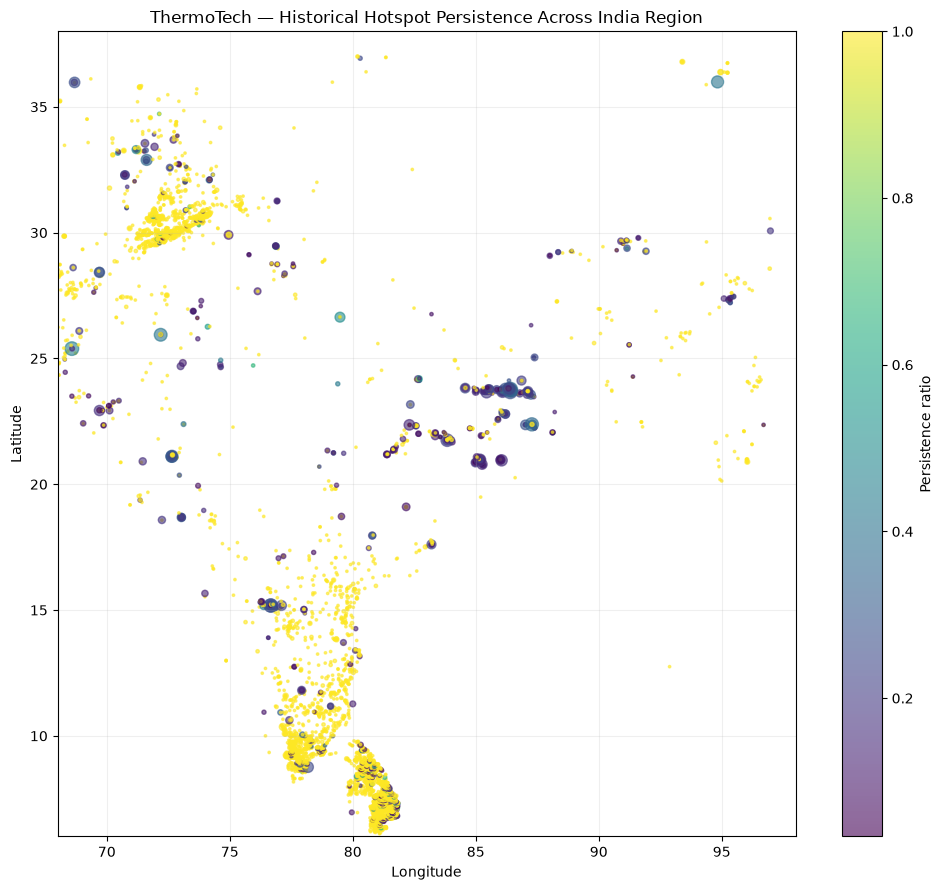

In [23]:
plt.figure(figsize=(10, 9))
scatter = plt.scatter(
    baseline["lon_grid"], baseline["lat_grid"],
    c=baseline["persistence_ratio"],
    s=baseline["detection_count"] * 3,
    alpha=0.6,
)
plt.xlim(68, 98)
plt.ylim(6, 38)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("ThermoTech — Historical Hotspot Persistence Across India Region")
plt.colorbar(scatter, label="Persistence ratio")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 11. Save the baseline dataset

Two outputs go forward to Notebook 03:
- `firms_baseline.csv` — one row per grid cell, with historical stats and persistence features.
- `firms_recent_scored.csv` — the recent window, now carrying baseline stats and anomaly z-scores per detection.

Notebook 03 will join these locations against OpenStreetMap to see whether persistent cells sit on known industrial/built-up land, versus open land or forest.

In [24]:
baseline_file = PROCESSED_DIR / "firms_baseline.csv"
scored_file = PROCESSED_DIR / "firms_recent_scored.csv"

baseline.to_csv(baseline_file, index=False)
scored.to_csv(scored_file, index=False)

print(f"Saved: {baseline_file} ({len(baseline)} grid cells)")
print(f"Saved: {scored_file} ({len(scored)} recent detections)")

Saved: c:\Users\ASUS\Documents\Sidra\ThermoTech\data\processed\firms_baseline.csv (4855 grid cells)
Saved: c:\Users\ASUS\Documents\Sidra\ThermoTech\data\processed\firms_recent_scored.csv (1112 recent detections)


# 12. Phase 2 checkpoint ✅

Before moving on, confirm:

- [ ] Recent window loaded from Notebook 01
- [ ] ~60 days of historical FIRMS data downloaded in 5-day chunks
- [ ] Historical chunks combined and deduplicated
- [ ] Historical data cleaned with the same rules as Notebook 01
- [ ] Grid cells built on both historical and recent data
- [ ] Per-cell baseline stats computed (count, mean/std FRP, first/last seen)
- [ ] Persistence features computed (active days, persistence ratio, recurring flag)
- [ ] Recent detections scored against the baseline (FRP z-score)
- [ ] Top anomalous detections inspected
- [ ] Persistent hotspots mapped
- [ ] Baseline + scored datasets saved

### Next notebook

`03_osm_context.ipynb`

Core idea:

**LOCATION ≠ IDENTITY**

A persistent hotspot tells us *something* keeps generating heat there — but not *what*. The next notebook joins our grid cells against OpenStreetMap to check whether they sit on industrial land, built-up areas, agricultural land, or forest, giving each persistent location real-world context before we engineer ML features.